### Etap 3

Ostatnia część projektu związana jest z opracowaniem modelu regresji (2,5 pkt.), poprzez
zastosowanie poznanych na wykładzie i ćwiczeniach laboratoryjnych metodach doboru cech
(2,5 pkt.) i regularyzacji (2,5 pkt.) oraz opracowanie raportu opisującego przeprowadzone prace,
jak i wyciągnięte wnioski z otrzymanych wyników/zależności (2,5 pkt.).

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Wczytanie zbioru danych

In [2]:
df = pd.read_csv('data/df_merged_without_outliers.csv')

### Transformacje zmiennych, aby ich rozkład był bardziej podobny do normalnego

Lista atrybutów o rozkładzie prawo skośnym:

In [3]:
right_skewed = np.array(['TotalPop', 'Hispanic', 'Black', 'Native', 'Asian', 'Pacific', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome', 'PublicWork', 'SelfEmployed', 'FamilyWork', 'Average_House_Price'], dtype=object)

Lista atrybutów o rozkładzie lewo skośnym:

In [4]:
left_skewed = np.array(['White', 'Drive', 'PrivateWork'], dtype=object)

Wybranie odpowiedniej podstawy logarytmu z przedziału [1.5, 2.0, 2.5, ..., 10.0] przy użyciu testu statystycznego Shapiro-Wilk. Jeżeli logarytmowanie nie pomoże, histogram dla logarytmowanych warotści nie będzie wyświetlany.

<Figure size 1000x2500 with 0 Axes>

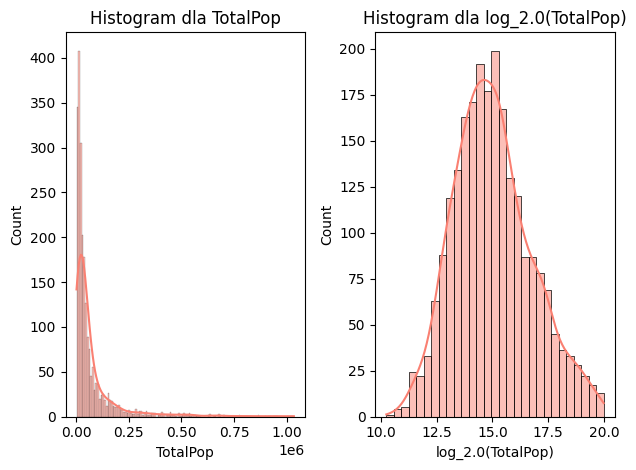

<Figure size 1000x2500 with 0 Axes>

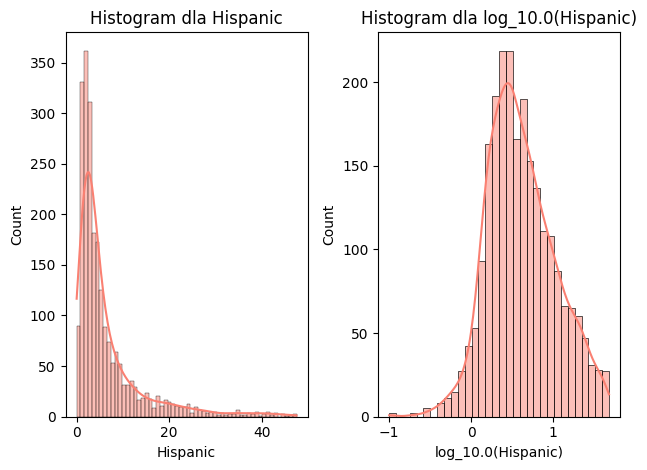

<Figure size 1000x2500 with 0 Axes>

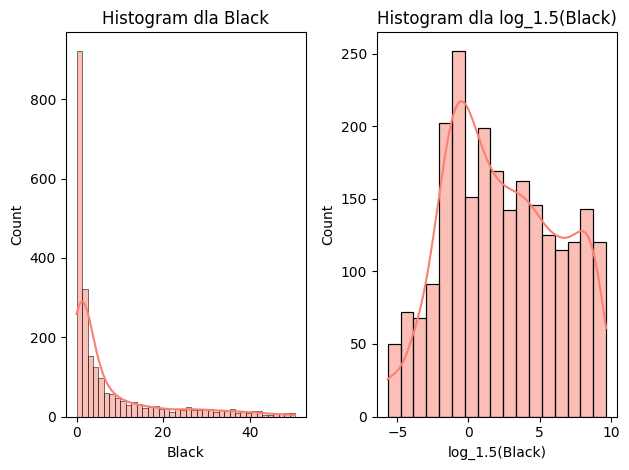

<Figure size 1000x2500 with 0 Axes>

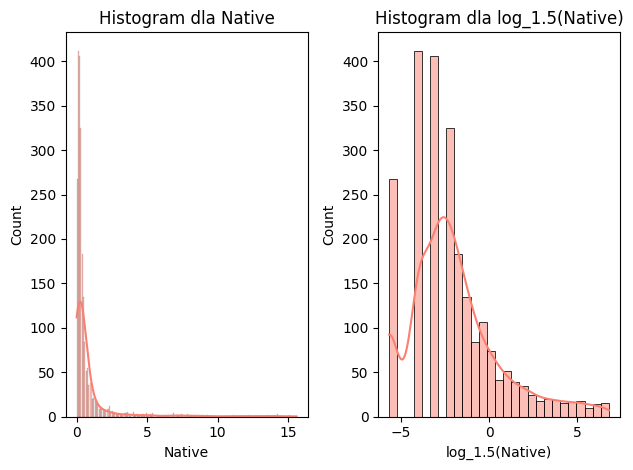

<Figure size 1000x2500 with 0 Axes>

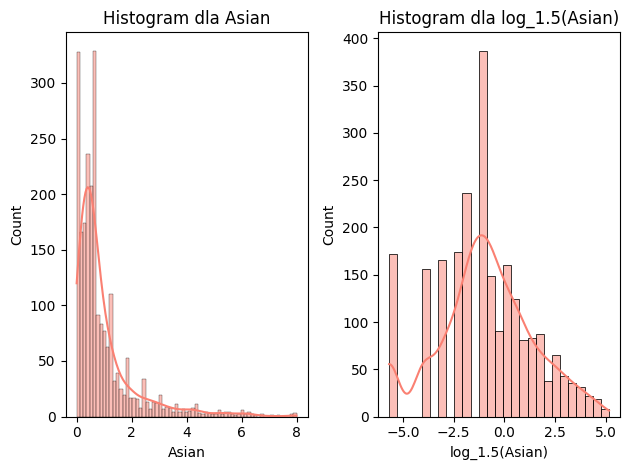

<Figure size 1000x2500 with 0 Axes>

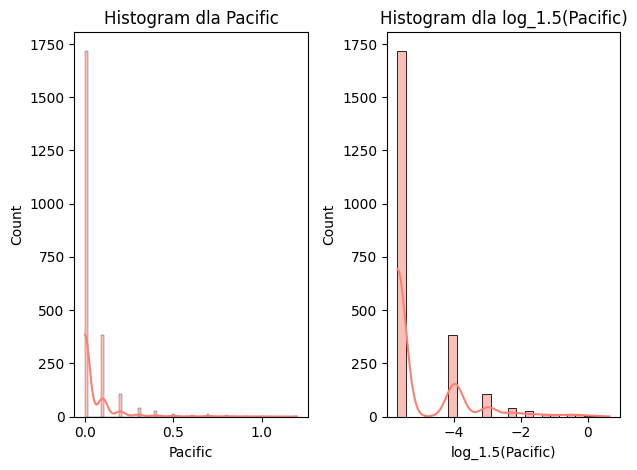

<Figure size 1000x2500 with 0 Axes>

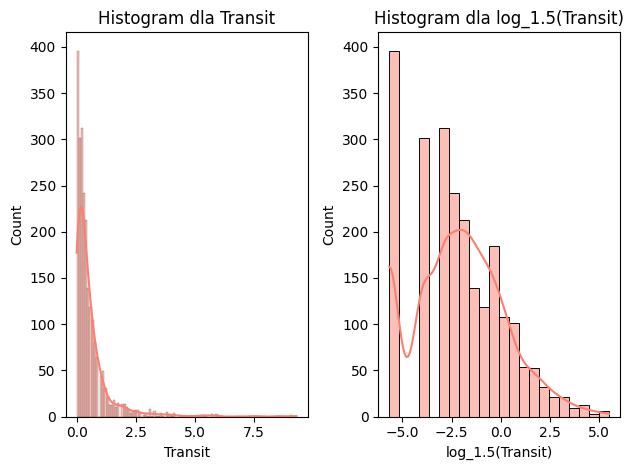

<Figure size 1000x2500 with 0 Axes>

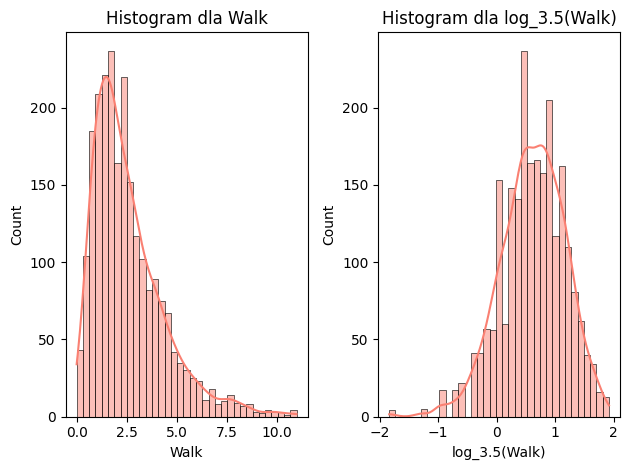

<Figure size 1000x2500 with 0 Axes>

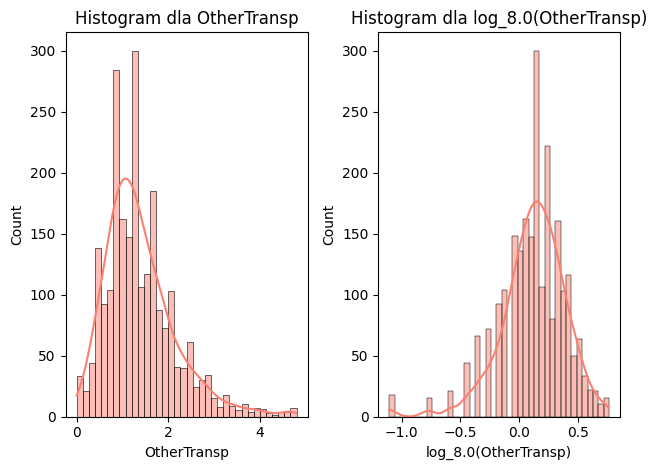

<Figure size 1000x2500 with 0 Axes>

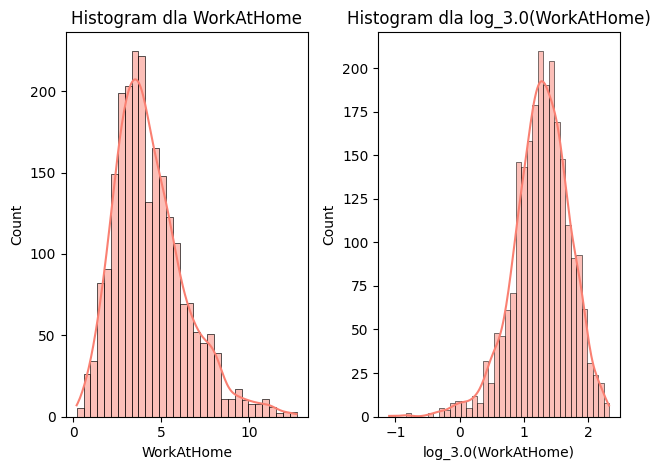

<Figure size 1000x2500 with 0 Axes>

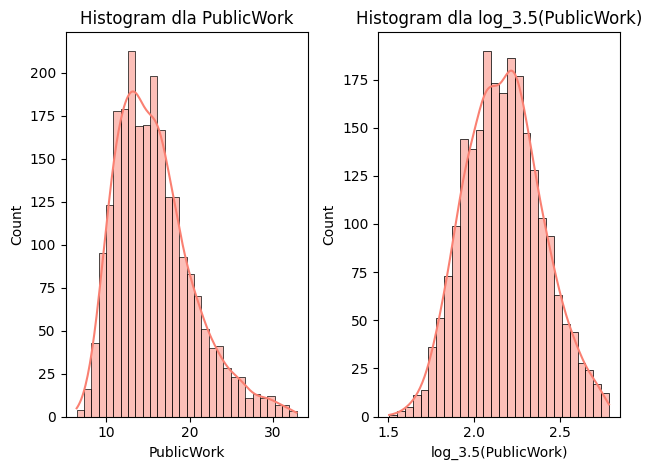

<Figure size 1000x2500 with 0 Axes>

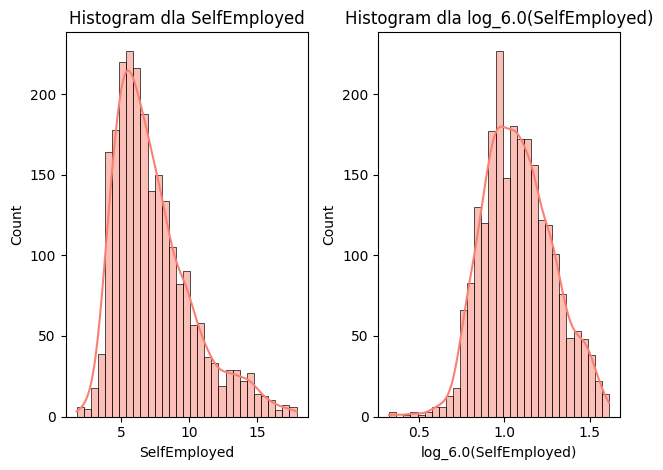

<Figure size 1000x2500 with 0 Axes>

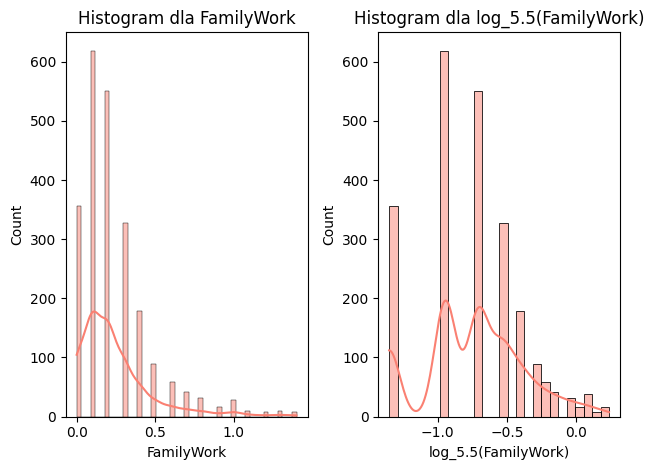

<Figure size 1000x2500 with 0 Axes>

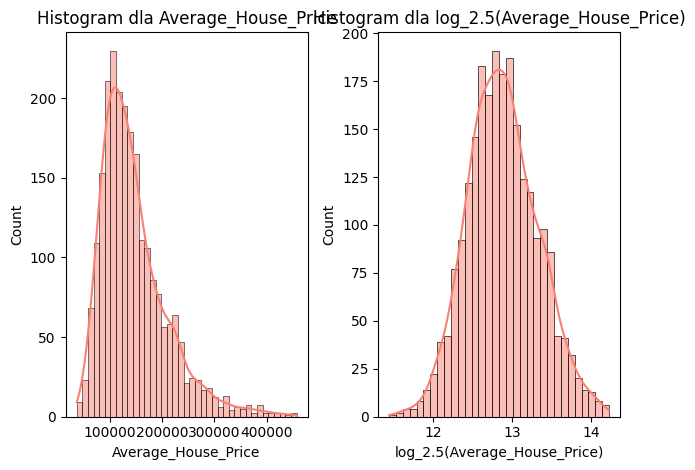

In [5]:
from scripts.right_skewed_to_normal import to_normal

for attr in right_skewed:
    df = to_normal(df, attr)

Dla wszystkich atrybutów poza `Pacific` logarytmowanie pomogło uzyskać rozkład bardziej zbliżony do normalnego.

Podnoszenie do potęgi, aby z rozkładu prawoskośnego przejsć na bardziej przypominający normalny. Wybranie odpowiedniego wykładnika z przedziału [1.5, 2.0, 2.5, ..., 10.0] przy użyciu testu statystycznego Shapiro-Wilk. Jeżeli podnoszenie do potęgi nie pomoże, histogram dla logarytmowanych warotści nie będzie wyświetlany.

<Figure size 1000x2500 with 0 Axes>

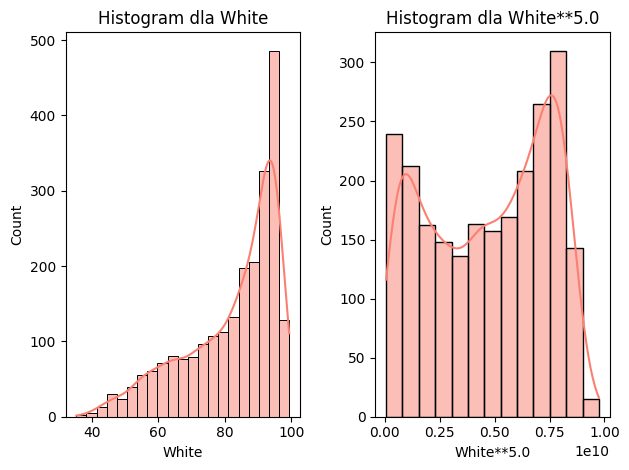

<Figure size 1000x2500 with 0 Axes>

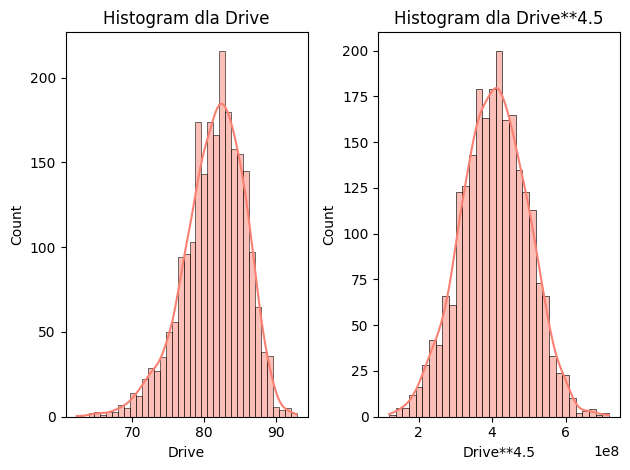

<Figure size 1000x2500 with 0 Axes>

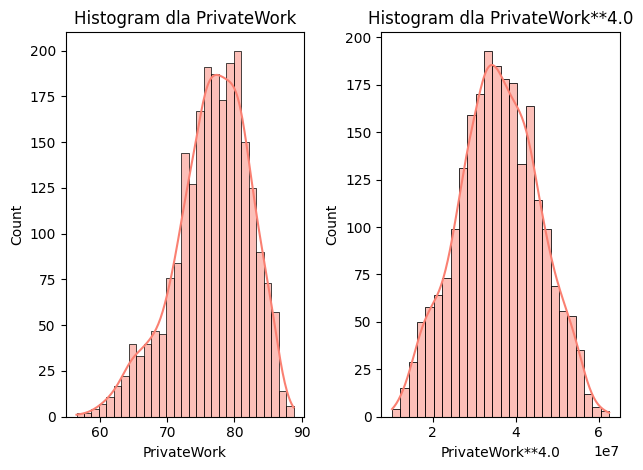

In [6]:
from scripts.left_skewed_to_normal import to_normal

for attr in left_skewed:
    df = to_normal(df, attr)

Dla wszystkich atrybutów z rozkładem prawoskośnym potęgowanie pomogło uzyskać rozkład bardziej normalny, jednakże dla atrybutu `White` zmieniło rozkład z jednomodalnego na dwumodalny.

### Macierz korelacji, po dodaniu nowych danych

Spojrzeć na public Work i Private Work, aby usunąć, któryś z tych i podobnie z White i Black

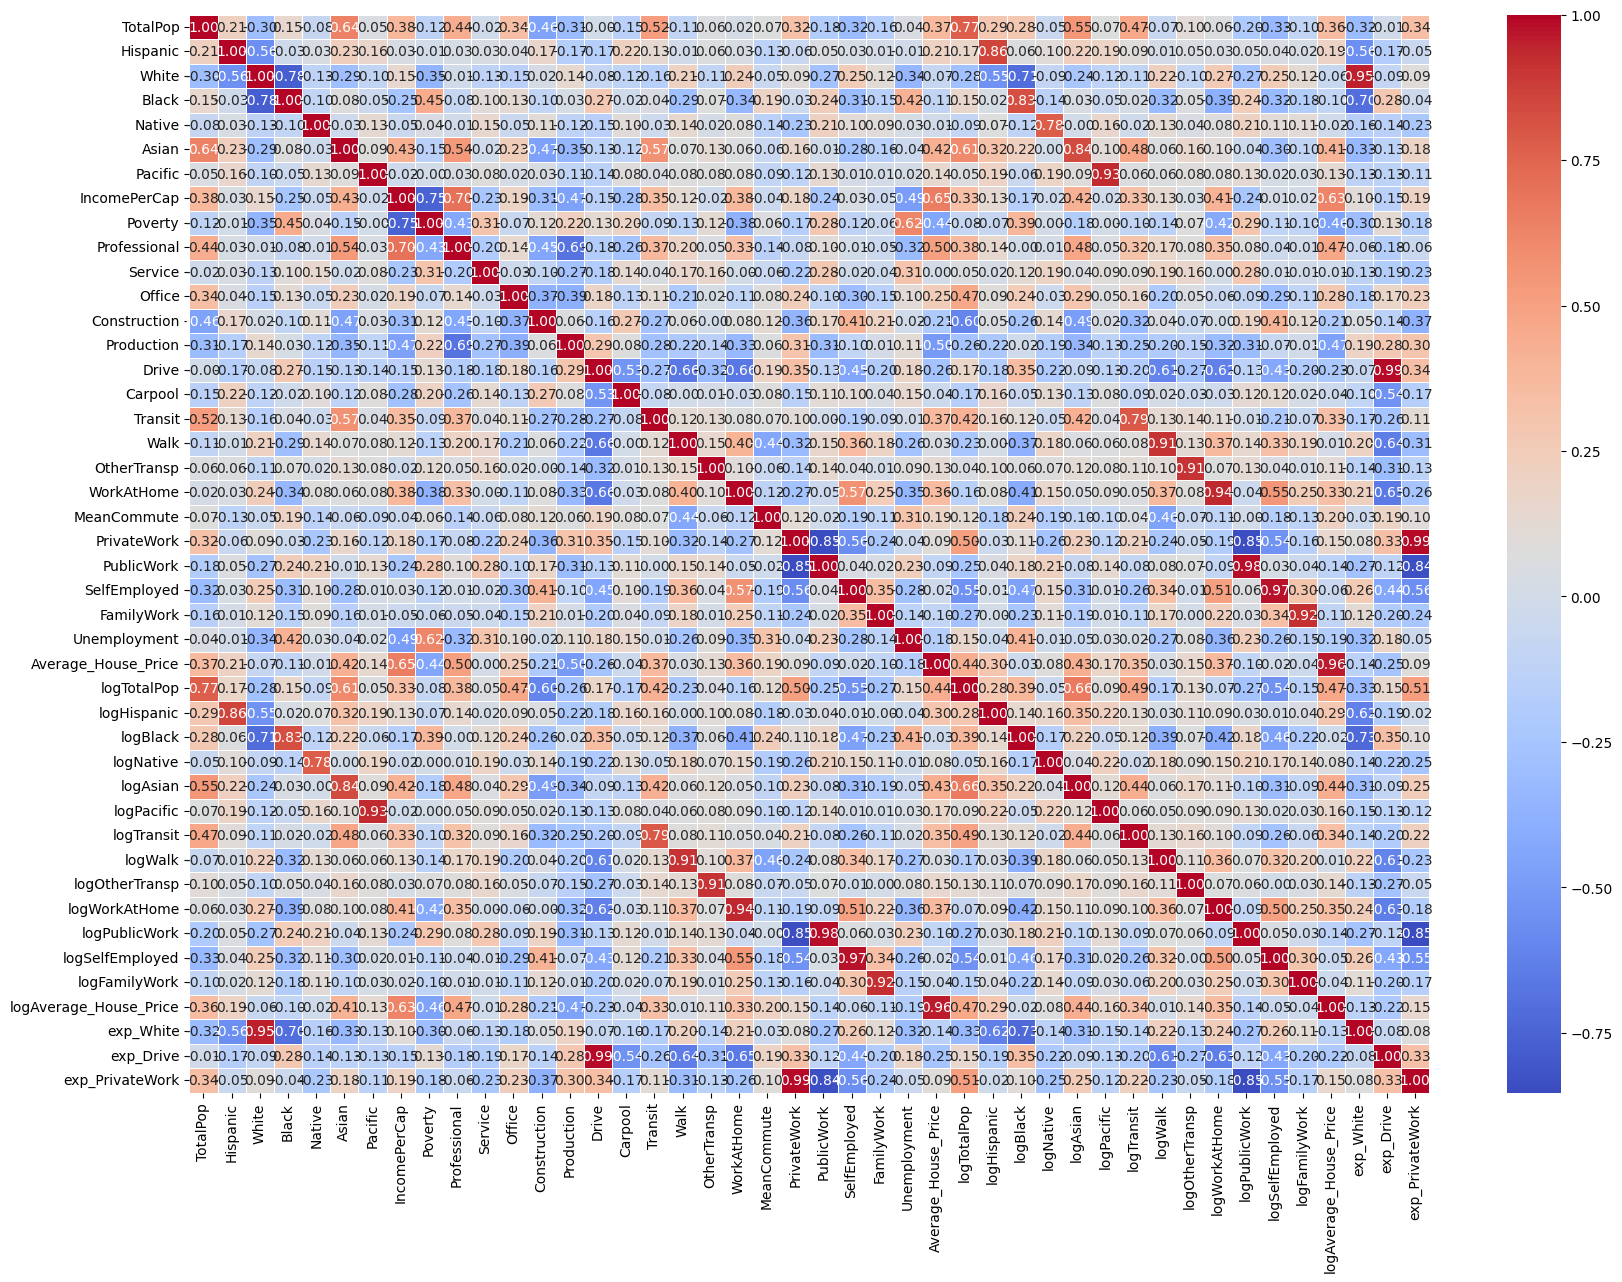

In [7]:
correlation_matrix = df.iloc[:,3:].corr()

plt.figure(figsize=(20, 14))
heatmap = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt=".2f", linewidths=0.5)

Każda z dodanych nowo atrybutów, po przetranformowaniu cech ma wysoką korelację z atrybutem przed transformacją, więc należy usunąć któreś z tych par, także pozbędziemy się danych, które po transformacji mają rozkład bardziej zgodny z normalnym

In [8]:
features = df.columns.tolist()[3:]
left_skewed_list = left_skewed.tolist()
right_skewed_list = right_skewed.tolist()
filtered_features = [attr for attr in features if attr not in left_skewed_list]
filtered_features2 = [attr for attr in filtered_features if attr not in right_skewed_list]

df = df[df.columns.tolist()[:3] + filtered_features2]
display(df.columns.tolist())

['Unnamed: 0',
 'State',
 'County',
 'IncomePerCap',
 'Poverty',
 'Professional',
 'Service',
 'Office',
 'Construction',
 'Production',
 'Carpool',
 'MeanCommute',
 'Unemployment',
 'logTotalPop',
 'logHispanic',
 'logBlack',
 'logNative',
 'logAsian',
 'logPacific',
 'logTransit',
 'logWalk',
 'logOtherTransp',
 'logWorkAtHome',
 'logPublicWork',
 'logSelfEmployed',
 'logFamilyWork',
 'logAverage_House_Price',
 'exp_White',
 'exp_Drive',
 'exp_PrivateWork']

### Macierz korelacji, po usunięciu elemntów które można było przetransformować

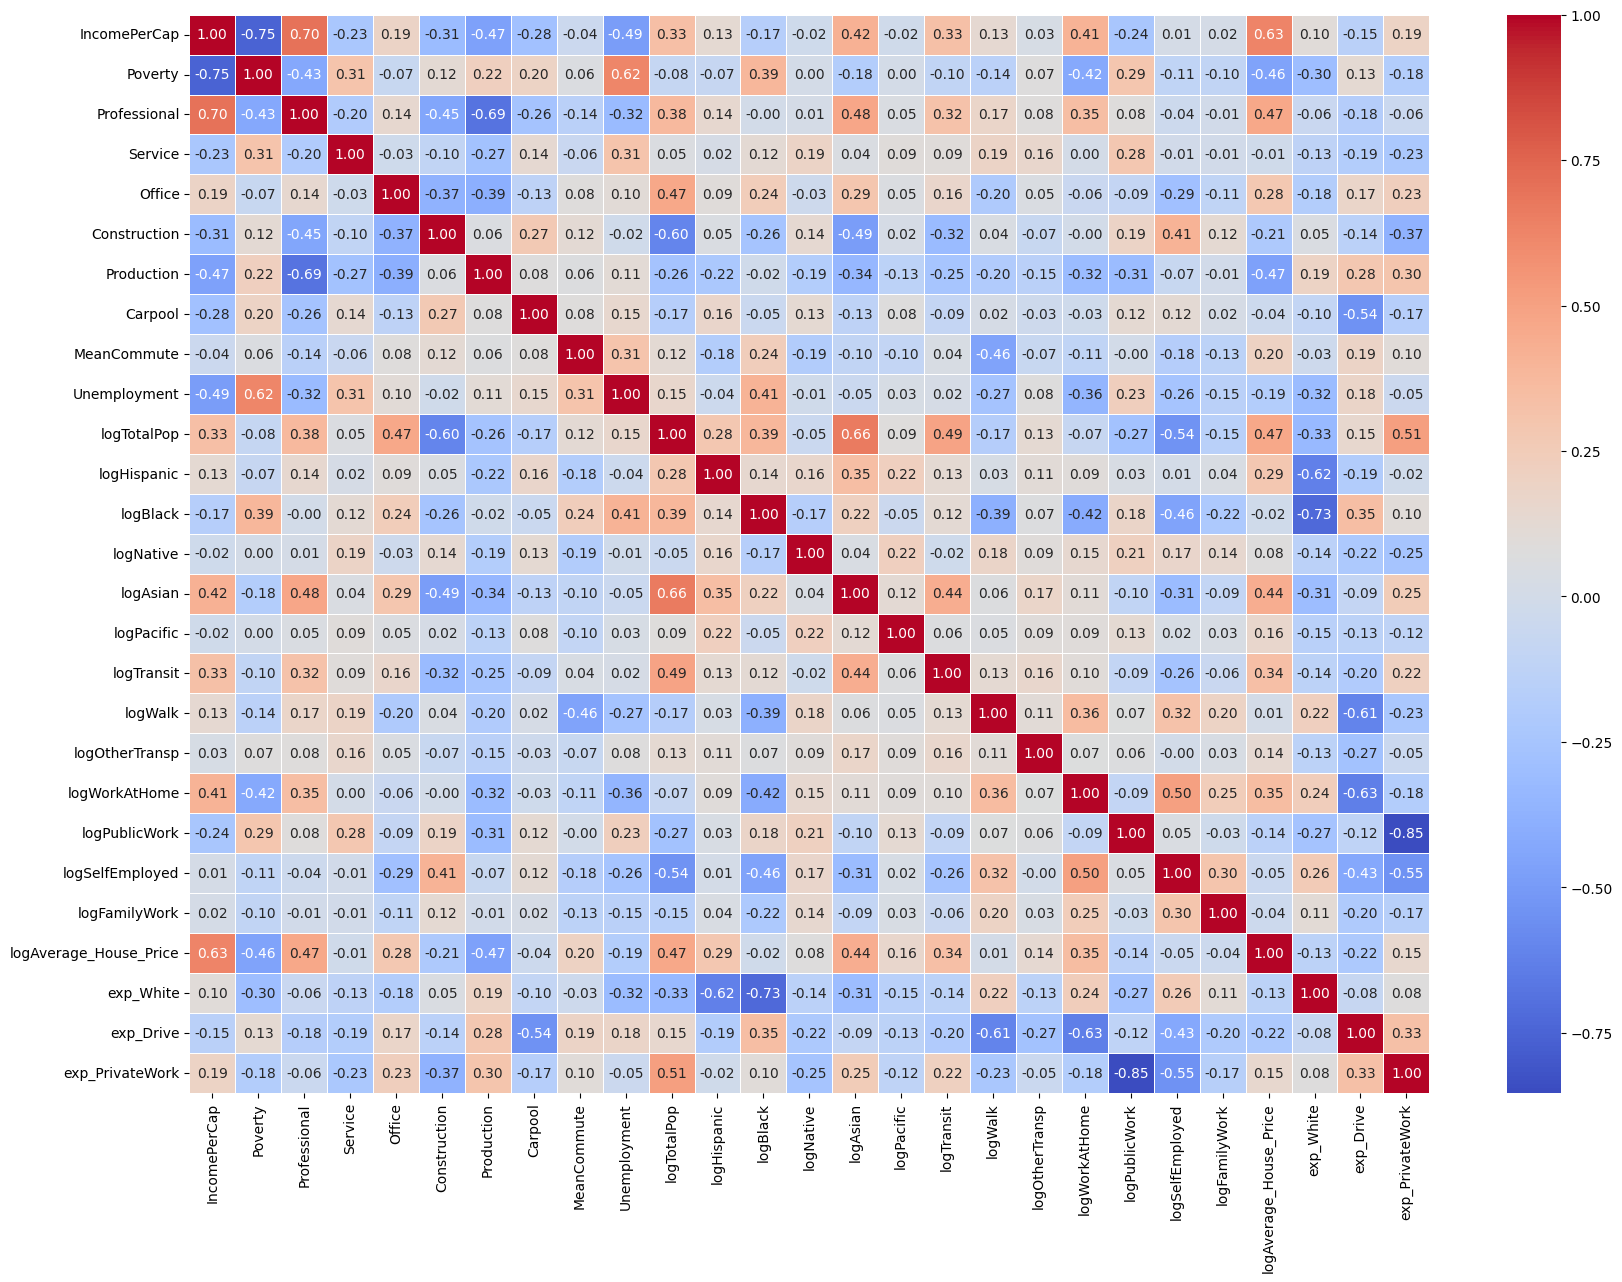

In [9]:
correlation_matrix = df.iloc[:,3:].corr()

plt.figure(figsize=(20, 14))
heatmap = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt=".2f", linewidths=0.5)

Przetransformowane atrybuty `logPublicWork` i `exp_PrivateWork` mają wysoką korelację (-0,85), więc należy jeden z nich usunąć. Usuniemy ten z mniejszą korelacją z atrybutem decyzyjnym, czyli `exp_PrivateWork`.

Podobnie sytuacją wygląda z atrybutami:
 - `logBlack` i `exp_White` (korelacja 0,73), dlatego usuniemy `exp_White`.
 - `Production` i `Professional` (korelacja 0,69), dlatego usuniemy `Production`


In [10]:
df.drop(columns = ['exp_PrivateWork', 'exp_White', 'Production'], inplace=True)

In [11]:
df

,Unnamed: 0,State,County,IncomePerCap,Poverty,Professional,Service,Office,Construction,Carpool,...,logPacific,logTransit,logWalk,logOtherTransp,logWorkAtHome,logPublicWork,logSelfEmployed,logFamilyWork,logAverage_House_Price,exp_Drive
0,0,Alabama,Autauga County,27824,13.7,35.3,18.0,23.2,8.1,9.6,...,-5.678874,-3.969362,-0.284711,0.161809,0.869744,2.403185,0.971373,-0.944091,13.116266,5.099342e+08
1,1,Alabama,Baldwin County,29364,11.8,35.7,18.2,25.6,9.7,7.6,...,-5.678874,-3.969362,-0.084103,0.087678,1.584241,2.047434,1.036020,-0.944091,13.427706,4.761912e+08
2,2,Alabama,Barbour County,17561,27.2,25.0,16.8,22.6,11.5,11.1,...,-5.678874,-2.259851,0.664858,0.282666,0.306270,2.358715,1.053194,-0.537493,12.594089,4.442108e+08
3,3,Alabama,Bibb County,20911,15.2,24.4,17.6,19.7,15.9,9.5,...,-5.678874,-0.550340,-0.731416,0.282666,0.427816,2.284711,1.036020,-0.537493,12.901011,5.206819e+08
4,4,Alabama,Blount County,22021,15.6,28.5,12.9,23.3,15.8,10.2,...,-5.678874,-3.969362,-0.553295,-0.333333,0.717685,1.983541,0.787487,-0.944091,13.006035,5.316049e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2322,2887,Wyoming,Sheridan County,31643,6.8,41.1,17.5,20.2,12.1,10.9,...,-5.678874,-2.969362,0.976861,-0.107309,1.584241,2.474604,1.036020,-0.706247,13.615051,3.561657e+08
2323,2889,Wyoming,Sweetwater County,31700,12.0,27.7,16.1,20.0,20.8,14.4,...,-1.259851,2.449660,0.849890,0.161809,0.427816,2.302751,0.759575,-1.350689,13.402725,3.194315e+08
2324,2891,Wyoming,Uinta County,27115,14.9,30.4,19.4,18.1,16.1,14.9,...,-5.678874,3.018202,0.145536,0.161809,0.675340,2.452733,1.061586,-0.406598,13.245697,3.175833e+08
2325,2892,Wyoming,Washakie County,27345,12.8,32.1,16.3,17.6,18.8,10.2,...,-5.678874,-5.678874,1.553295,0.161809,1.369070,2.471000,1.174340,-0.706247,13.125555,3.139119e+08


In [12]:
df.columns.to_list()

['Unnamed: 0',
 'State',
 'County',
 'IncomePerCap',
 'Poverty',
 'Professional',
 'Service',
 'Office',
 'Construction',
 'Carpool',
 'MeanCommute',
 'Unemployment',
 'logTotalPop',
 'logHispanic',
 'logBlack',
 'logNative',
 'logAsian',
 'logPacific',
 'logTransit',
 'logWalk',
 'logOtherTransp',
 'logWorkAtHome',
 'logPublicWork',
 'logSelfEmployed',
 'logFamilyWork',
 'logAverage_House_Price',
 'exp_Drive']

In [32]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, Ridge
from sklearn.metrics import mean_squared_error, r2_score, RocCurveDisplay, classification_report, confusion_matrix,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SequentialFeatureSelector

### Dobór cech dla modelu regresji liniowej przy użyciu metody zachłannej

Do ewaluacji użyliśmy walidacji krzyżowej podzielonego na 5 części zbioru, ponieważ zawiera on dużo danych (> 1000 rekordów).

In [14]:
from scripts.greedy_features import find_best_features

features = df.columns[3:]
find_best_features(df[features], 'IncomePerCap')

['Poverty'] 10218987.616236243

['Poverty', 'Professional'] 6181474.142286185

['Poverty', 'Professional', 'logAverage_House_Price'] 5350340.812296448

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork'] 5067159.4692616565

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit'] 4951472.480056725

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool'] 4866808.40423652

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'logPacific'] 4791363.011156088

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'logPacific', 'Unemployment'] 4783766.0784379

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'logPacific', 'Unemployment', 'logAsian'] 4777355.598003736

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'logPacific', 

Weryfikacja, czy skalowanie, lub standaryzacja zmiennych zmienia coś 

In [15]:
from sklearn.preprocessing import StandardScaler

std_dev_target = df['IncomePerCap'].std()

df_stantard = df[:]
scaler = StandardScaler()
columns_to_scale = df.columns[3:]
df_stantard[columns_to_scale] = scaler.fit_transform(df_stantard[columns_to_scale])

find_best_features(df_stantard[features], 'IncomePerCap', is_standarized=True, std_dev=std_dev_target)

['Poverty'] 0.43662735635206307

['Poverty', 'Professional'] 0.2641162524570241

['Poverty', 'Professional', 'logAverage_House_Price'] 0.2286043639727941

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork'] 0.2165048560938477

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit'] 0.21156189049316304

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool'] 0.2079444429541688

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'logPacific'] 0.20472088267924365

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'logPacific', 'Unemployment'] 0.20439628803506804

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'logPacific', 'Unemployment', 'logAsian'] 0.20412238701570792

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool',

In [16]:
from sklearn.preprocessing import MinMaxScaler

min_target = df['IncomePerCap'].min()
max_target = df['IncomePerCap'].max()
range_target = max_target - min_target

df_normalized = df[:]
scaler = MinMaxScaler()
columns_to_scale = df.columns[3:]
df_normalized[columns_to_scale] = scaler.fit_transform(df_normalized[columns_to_scale])

find_best_features(df_normalized[features], 'IncomePerCap', is_normalized=True, range_minmax=range_target)

['Poverty'] 0.009372463008337955

['Poverty', 'Professional'] 0.005669410700089794

['Poverty', 'Professional', 'logAverage_House_Price'] 0.004907127127307204

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork'] 0.004647404074308482

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit'] 0.004541300410463497

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool'] 0.004463649771421794

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'logPacific'] 0.00439445415416981

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'logPacific', 'Unemployment'] 0.004387486539220855

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'logPacific', 'Unemployment', 'logAsian'] 0.004381607092744239

['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit'

Ani dodatkowa standaryzacja, ani normamlizacja, nie mają praktycznie żadnego wpływu na błąd modelu.

In [17]:
# Cechy, dla których błąd był najmniejszy:
best_features = ['Poverty', 'Professional', 'logAverage_House_Price', 'logPublicWork', 'logTransit', 'Carpool', 'Unemployment', 'logFamilyWork', 'logSelfEmployed', 'logAsian', 'logBlack', 'logOtherTransp', 'Office', 'logTotalPop']

### Model regresji liniowej

In [18]:
def linear_regression(x_train, x_test, y_train, y_test):
    regresor = LinearRegression()
    regresor.fit(x_train, y_train)
    y_pred_train = regresor.predict(x_train)
    y_pred_test = regresor.predict(x_test)
    e_train= mean_squared_error(y_train, y_pred_train)
    e_test = mean_squared_error(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    plt.suptitle("Regresja Wieloraka")

    axs[0].scatter(y_train, y_pred_train, alpha=0.6, color="blue", label="Train")
    axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
    axs[0].set_xlabel("Rzeczywiste wartości")
    axs[0].set_ylabel("Przewidywane wartości")
    axs[0].set_title("Rzeczywiste vs Przewidywane (Train)")
    axs[0].legend()

    axs[1].scatter(y_test, y_pred_test, alpha=0.6, color="green", label="Test")
    axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")
    axs[1].set_xlabel("Rzeczywiste wartości")
    axs[1].set_ylabel("Przewidywane wartości")
    axs[1].set_title("Rzeczywiste vs Przewidywane (Test)")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    return e_train, e_test, r2_train, r2_test, regresor.coef_


Dla cech początkowych:

In [19]:
X1 = df[features].iloc[:,1:]
X1

,Poverty,Professional,Service,Office,Construction,Carpool,MeanCommute,Unemployment,logTotalPop,logHispanic,...,logPacific,logTransit,logWalk,logOtherTransp,logWorkAtHome,logPublicWork,logSelfEmployed,logFamilyWork,logAverage_House_Price,exp_Drive
0,13.7,35.3,18.0,23.2,8.1,9.6,25.8,5.2,15.748114,0.447158,...,-5.678874,-3.969362,-0.284711,0.161809,0.869744,2.403185,0.971373,-0.944091,13.116266,5.099342e+08
1,11.8,35.7,18.2,25.6,9.7,7.6,27.0,5.5,17.633684,0.653213,...,-5.678874,-3.969362,-0.084103,0.087678,1.584241,2.047434,1.036020,-0.944091,13.427706,4.761912e+08
2,27.2,25.0,16.8,22.6,11.5,11.1,23.4,12.4,14.677389,0.633468,...,-5.678874,-2.259851,0.664858,0.282666,0.306270,2.358715,1.053194,-0.537493,12.594089,4.442108e+08
3,15.2,24.4,17.6,19.7,15.9,9.5,30.0,8.2,14.462822,0.397940,...,-5.678874,-0.550340,-0.731416,0.282666,0.427816,2.284711,1.036020,-0.537493,12.901011,5.206819e+08
4,15.6,28.5,12.9,23.3,15.8,10.2,35.0,4.9,15.815483,0.959041,...,-5.678874,-3.969362,-0.553295,-0.333333,0.717685,1.983541,0.787487,-0.944091,13.006035,5.316049e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2322,6.8,41.1,17.5,20.2,12.1,10.9,16.0,3.1,14.870991,0.633468,...,-5.678874,-2.969362,0.976861,-0.107309,1.584241,2.474604,1.036020,-0.706247,13.615051,3.561657e+08
2323,12.0,27.7,16.1,20.0,20.8,14.4,20.5,5.2,15.442425,1.206826,...,-1.259851,2.449660,0.849890,0.161809,0.427816,2.302751,0.759575,-1.350689,13.402725,3.194315e+08
2324,14.9,30.4,19.4,18.1,16.1,14.9,19.9,6.4,14.341449,0.963788,...,-5.678874,3.018202,0.145536,0.161809,0.675340,2.452733,1.061586,-0.406598,13.245697,3.175833e+08
2325,12.8,32.1,16.3,17.6,18.8,10.2,14.3,6.1,13.010878,1.155336,...,-5.678874,-5.678874,1.553295,0.161809,1.369070,2.471000,1.174340,-0.706247,13.125555,3.139119e+08


C:\Users\justy\AppData\Local\Temp\ipykernel_28688\2690550006.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
C:\Users\justy\AppData\Local\Temp\ipykernel_28688\2690550006.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")


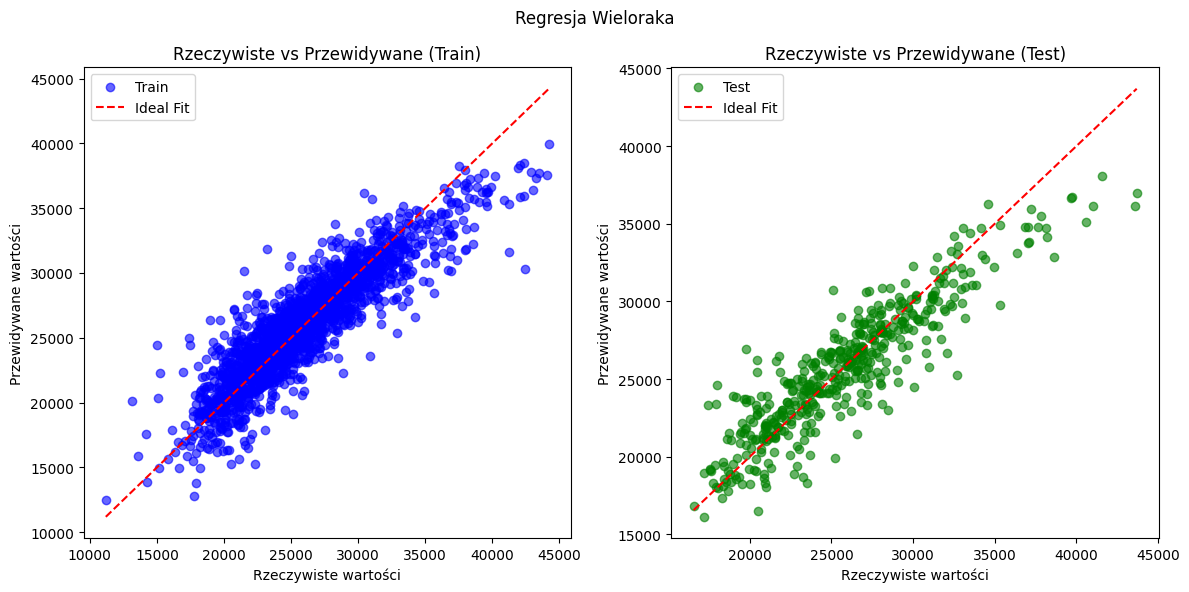

Mean Squared Error for train: 4573114.533389418
Mean Squared Error for test: 4480379.550599861
R2 Score for train: 0.8036263939910947
R2 Score for test: 0.8122509058011071
Coefficients: [-12997.47244264  11996.59301217   1296.8458752    1233.82684507
    987.2745449   -3790.87114306   -184.88425201  -1122.27854509
   -221.91131261   -690.46336726    886.78343156    -81.79625161
    994.35161555  -1505.96676201   1499.24344799  -1366.66518673
   -782.90811123  -2096.71884094  -3279.6077812    1461.78152208
   -395.34241883   5910.25016484  -3099.86088151]


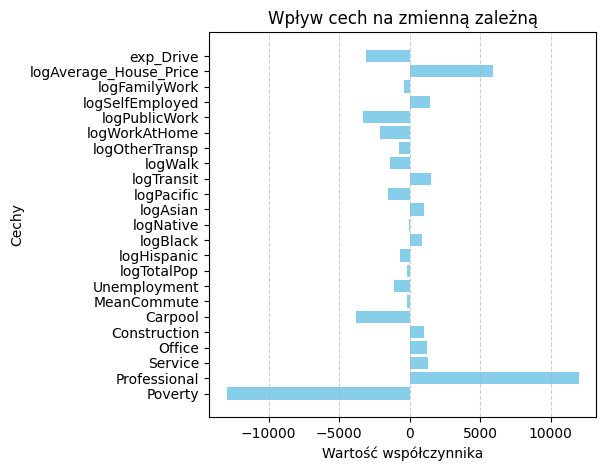

In [20]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, df['IncomePerCap'], test_size=0.2, random_state=42)

X_train1 = scaler.fit_transform(X_train1)
X_test1 = scaler.transform(X_test1)

e_train1, e_test1, r2_train1, r2_test1, coefs1 = linear_regression(X_train1, X_test1, y_train1, y_test1)
print('Mean Squared Error for train:', e_train1)
print('Mean Squared Error for test:', e_test1)
print('R2 Score for train:', r2_train1)
print('R2 Score for test:', r2_test1)
print('Coefficients:', coefs1)

plt.figure(figsize=(5, 5))
plt.barh(X1.columns.values, coefs1, color='skyblue')
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cechy")
plt.title("Wpływ cech na zmienną zależną")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


Wnioski:

Dla cech dobranych metodą zachłanną (krokową w przód):

In [21]:
y = df['IncomePerCap']
x = df[best_features]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
features = x_train.columns.values
features

array(['Poverty', 'Professional', 'logAverage_House_Price',
       'logPublicWork', 'logTransit', 'Carpool', 'Unemployment',
       'logFamilyWork', 'logSelfEmployed', 'logAsian', 'logBlack',
       'logOtherTransp', 'Office', 'logTotalPop'], dtype=object)

Użycie standaryzacji danych, aby bezpośrednio porównać, który z atrybutów opisującyh ma największy wpływ na atrybut decyzyjny.

In [22]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

C:\Users\justy\AppData\Local\Temp\ipykernel_28688\2690550006.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
C:\Users\justy\AppData\Local\Temp\ipykernel_28688\2690550006.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")


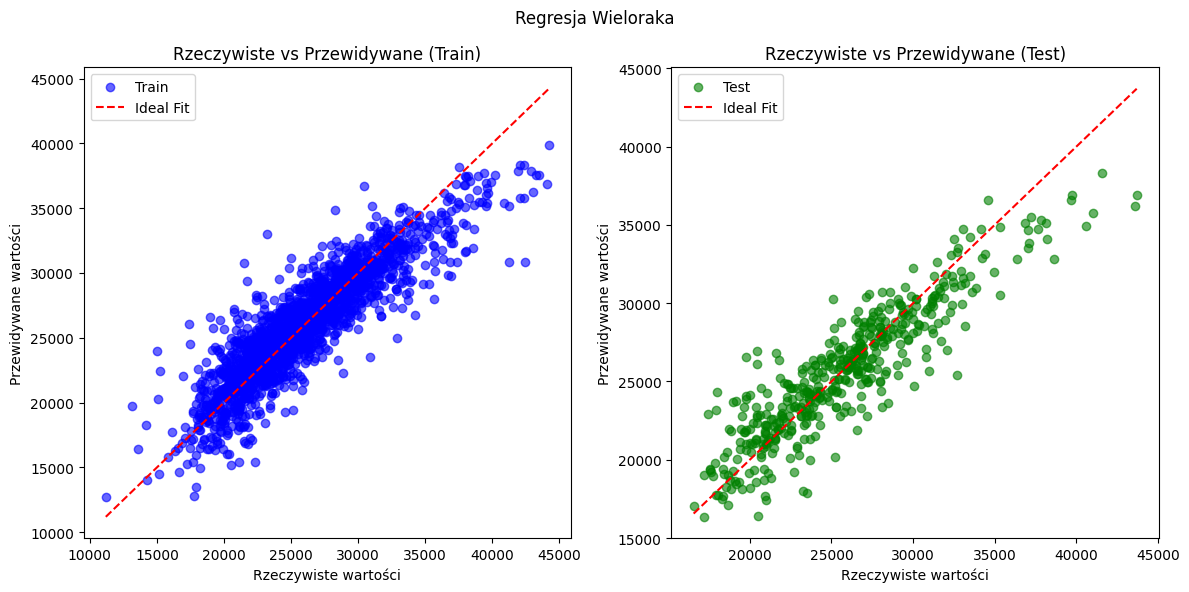

Mean Squared Error for train: 4706006.362868563
Mean Squared Error for test: 4517430.231263011
R2 Score for train: 0.7979199006213347
R2 Score for test: 0.8106983070412481
Coefficients: [-2095.88110166  1740.28273288   951.74682788  -538.43331045
   404.88295724  -324.91887765  -174.30669971  -110.08799519
   228.91827731   191.57606584   242.76604792   -26.12355171
   165.07237576  -169.33033023]


In [23]:
e_train, e_test, r2_train, r2_test, coefs = linear_regression(x_train, x_test, y_train, y_test)
print('Mean Squared Error for train:', e_train)
print('Mean Squared Error for test:', e_test)
print('R2 Score for train:', r2_train)
print('R2 Score for test:', r2_test)
print('Coefficients:', coefs)


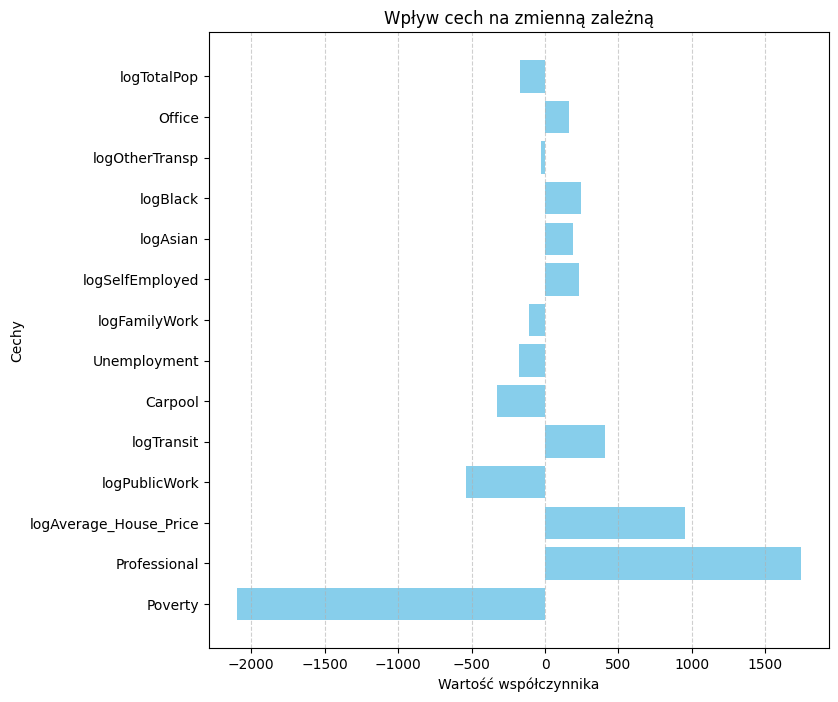

In [24]:
plt.figure(figsize=(8, 8))
plt.barh(best_features, coefs, color='skyblue')
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cechy")
plt.title("Wpływ cech na zmienną zależną")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [25]:
poly_regresor = PolynomialFeatures(degree=4)
x_poly = poly_regresor.fit_transform(x_train)

moznaby dla roznych stopni wielomianu, ale idk czy jest sens sie nad tym tak rozwodzic czy lepiej skupic sie na innych modelach

### Regularyzacja

In [31]:
def ridge_regression(X_train, X_test, y_train, y_test, alpha):
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_pred_train = ridge.predict(X_train)
    y_pred_test = ridge.predict(X_test)
    e_train = mean_squared_error(y_train, y_pred_train)
    e_test = mean_squared_error(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    plt.suptitle("Regresja Ridge")
    axs[0].scatter(y_train, y_pred_train, alpha=0.6, color="blue", label="Train")
    axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
    axs[0].set_xlabel("Rzeczywiste wartości")
    axs[0].set_ylabel("Przewidywane wartości")
    axs[0].set_title("Rzeczywiste vs Przewidywane (Train)")
    axs[0].legend()

    axs[1].scatter(y_test, y_pred_test, alpha=0.6, color="green", label="Test")
    axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")
    axs[1].set_xlabel("Rzeczywiste wartości")
    axs[1].set_ylabel("Przewidywane wartości")
    axs[1].set_title("Rzeczywiste vs Przewidywane (Test)")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    return e_train, e_test, r2_train, r2_test, ridge.coef_

In [66]:
def lasso_regression(X_train, X_test, y_train, y_test, alpha):
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    y_pred_train = lasso.predict(X_train)
    y_pred_test = lasso.predict(X_test)
    e_train = mean_squared_error(y_train, y_pred_train)
    e_test = mean_squared_error(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    plt.suptitle("Regresja Ridge")
    axs[0].scatter(y_train, y_pred_train, alpha=0.6, color="blue", label="Train")
    axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
    axs[0].set_xlabel("Rzeczywiste wartości")
    axs[0].set_ylabel("Przewidywane wartości")
    axs[0].set_title("Rzeczywiste vs Przewidywane (Train)")
    axs[0].legend()

    axs[1].scatter(y_test, y_pred_test, alpha=0.6, color="green", label="Test")
    axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")
    axs[1].set_xlabel("Rzeczywiste wartości")
    axs[1].set_ylabel("Przewidywane wartości")
    axs[1].set_title("Rzeczywiste vs Przewidywane (Test)")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    return e_train, e_test, r2_train, r2_test, lasso.coef_

In [26]:
df.iloc[:, 3:]

,IncomePerCap,Poverty,Professional,Service,Office,Construction,Carpool,MeanCommute,Unemployment,logTotalPop,...,logPacific,logTransit,logWalk,logOtherTransp,logWorkAtHome,logPublicWork,logSelfEmployed,logFamilyWork,logAverage_House_Price,exp_Drive
0,27824,13.7,35.3,18.0,23.2,8.1,9.6,25.8,5.2,15.748114,...,-5.678874,-3.969362,-0.284711,0.161809,0.869744,2.403185,0.971373,-0.944091,13.116266,5.099342e+08
1,29364,11.8,35.7,18.2,25.6,9.7,7.6,27.0,5.5,17.633684,...,-5.678874,-3.969362,-0.084103,0.087678,1.584241,2.047434,1.036020,-0.944091,13.427706,4.761912e+08
2,17561,27.2,25.0,16.8,22.6,11.5,11.1,23.4,12.4,14.677389,...,-5.678874,-2.259851,0.664858,0.282666,0.306270,2.358715,1.053194,-0.537493,12.594089,4.442108e+08
3,20911,15.2,24.4,17.6,19.7,15.9,9.5,30.0,8.2,14.462822,...,-5.678874,-0.550340,-0.731416,0.282666,0.427816,2.284711,1.036020,-0.537493,12.901011,5.206819e+08
4,22021,15.6,28.5,12.9,23.3,15.8,10.2,35.0,4.9,15.815483,...,-5.678874,-3.969362,-0.553295,-0.333333,0.717685,1.983541,0.787487,-0.944091,13.006035,5.316049e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2322,31643,6.8,41.1,17.5,20.2,12.1,10.9,16.0,3.1,14.870991,...,-5.678874,-2.969362,0.976861,-0.107309,1.584241,2.474604,1.036020,-0.706247,13.615051,3.561657e+08
2323,31700,12.0,27.7,16.1,20.0,20.8,14.4,20.5,5.2,15.442425,...,-1.259851,2.449660,0.849890,0.161809,0.427816,2.302751,0.759575,-1.350689,13.402725,3.194315e+08
2324,27115,14.9,30.4,19.4,18.1,16.1,14.9,19.9,6.4,14.341449,...,-5.678874,3.018202,0.145536,0.161809,0.675340,2.452733,1.061586,-0.406598,13.245697,3.175833e+08
2325,27345,12.8,32.1,16.3,17.6,18.8,10.2,14.3,6.1,13.010878,...,-5.678874,-5.678874,1.553295,0.161809,1.369070,2.471000,1.174340,-0.706247,13.125555,3.139119e+08


[np.float64(4639867.925765861), np.float64(4639867.926158333), np.float64(4639867.927335698), np.float64(4639867.932044779), np.float64(4639867.950878069), np.float64(4639868.026186967), np.float64(4639868.32722866), np.float64(4639869.5298468005), np.float64(4639874.327971972), np.float64(4639893.422354644), np.float64(4639969.025365184), np.float64(4640265.403238328)]
[np.float64(4831486.552964859), np.float64(4831484.985383043), np.float64(4831483.418660563), np.float64(4831480.287793261), np.float64(4831474.036366821), np.float64(4831461.574726926), np.float64(4831436.816141809), np.float64(4831387.95649462), np.float64(4831292.857286697), np.float64(4831113.059797021), np.float64(4830794.44302682), np.float64(4830316.271274233)]
Best lambda: 10.24
11


Text(0.5, 1.0, 'Współczynniki dla kolejnych wartości lambda')

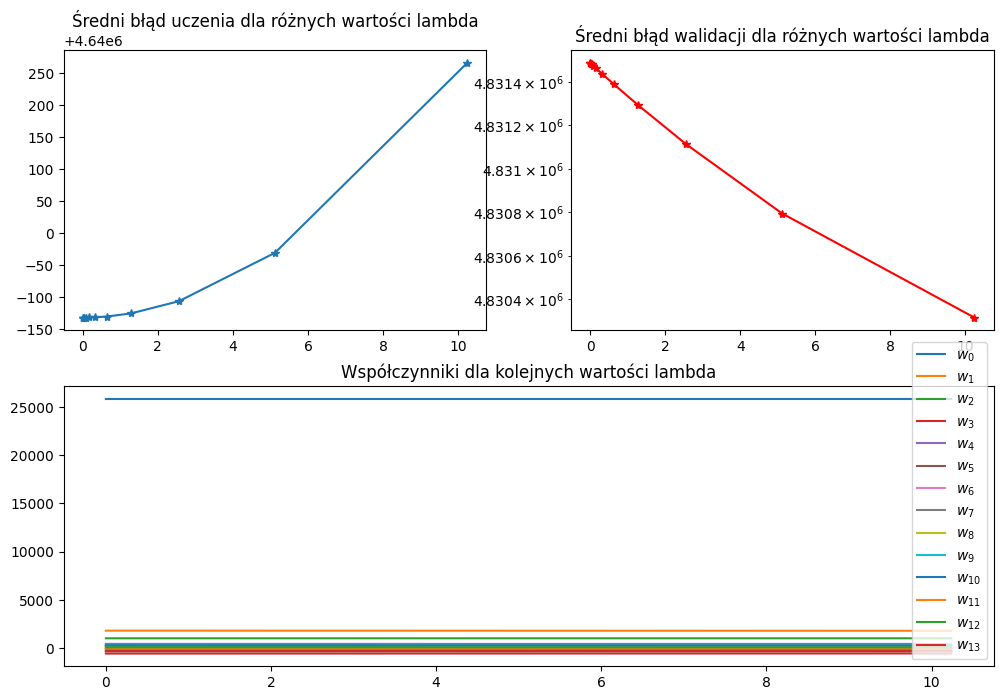

In [42]:
from sklearn.model_selection import cross_validate
import matplotlib.gridspec as gridspec

parameters = [0.01 * 2**i for i in range(11)]
parameters.insert(0, 0)
train_scores = []
test_scores = []
ws = []

for lamb in parameters:
    result = cross_validate(Ridge(alpha = lamb, fit_intercept=True), scaler.fit_transform(x), y, return_train_score = True, cv = 5, scoring = 'neg_mean_squared_error', return_estimator = True)
    train_scores.append(np.mean(-result['train_score']))
    test_scores.append(np.mean(-result['test_score']))
    best_model: Ridge = result['estimator'][np.argmax(result['test_score'])]
    coefficients = best_model.coef_
    coefficients[0] = best_model.intercept_
    # print(coefficients.flatten().tolist())
    ws.append(coefficients.flatten().tolist())

# print(ws)
print(train_scores)
print(test_scores)
print('Best lambda:', parameters[np.argmin(test_scores)])
gs = gridspec.GridSpec(2, 2)
fig = plt.figure(figsize=(12,8))

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(parameters, train_scores, '*-')
plt.title('Średni błąd uczenia dla różnych wartości lambda')


print(np.argmin(test_scores))
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(parameters, test_scores, '*-', color='red')
plt.yscale('log')
# ax2.set_ylim(0, 10**9)
plt.title('Średni błąd walidacji dla różnych wartości lambda')

# ax -> plt

ax3 = fig.add_subplot(gs[1, :])
for i in range(len(best_features)):
    ax3.plot(parameters, [w[i] for w in ws])
# ax3.set_ylim(-80, 60)
plt.legend([f'$w_{{{i}}}$' for i in range(len(best_features))], loc='lower right')
plt.title('Współczynniki dla kolejnych wartości lambda')

In [49]:
def ridge_find_alpha(x, y):
    parameters = [0.01 * 2**i for i in range(11)]
    parameters.insert(0, 0)
    train_scores = []
    test_scores = []
    ws = []

    for lamb in parameters:
        result = cross_validate(Ridge(alpha = lamb, fit_intercept=True), x, y, return_train_score = True, cv = 5, scoring = 'neg_mean_squared_error', return_estimator = True)
        train_scores.append(np.mean(-result['train_score']))
        test_scores.append(np.mean(-result['test_score']))
        best_model: Ridge = result['estimator'][np.argmax(result['test_score'])]
        coefficients = best_model.coef_
        coefficients[0] = best_model.intercept_
        ws.append(coefficients.flatten().tolist())

    print(train_scores)
    print(test_scores)
    best_lambda = parameters[np.argmin(test_scores)]
    print('Best lambda:', best_lambda)
    gs = gridspec.GridSpec(2, 2)
    fig = plt.figure(figsize=(12,8))

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(parameters, train_scores, '*-')
    plt.title('Średni błąd uczenia dla różnych wartości lambda')

    print(np.argmin(test_scores))
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(parameters, test_scores, '*-', color='red')
    plt.yscale('log')
    plt.title('Średni błąd walidacji dla różnych wartości lambda')

    ax3 = fig.add_subplot(gs[1, :])
    for i in range(len(best_features)):
        ax3.plot(parameters, [w[i] for w in ws])
    plt.legend([f'$w_{{{i}}}$' for i in range(len(best_features))], loc='lower right')
    plt.title('Współczynniki dla kolejnych wartości lambda')

    return best_lambda



[np.float64(4639867.925765861), np.float64(4639867.926158333), np.float64(4639867.927335699), np.float64(4639867.932044779), np.float64(4639867.950878068), np.float64(4639868.026186967), np.float64(4639868.32722866), np.float64(4639869.5298468005), np.float64(4639874.327971971), np.float64(4639893.422354644), np.float64(4639969.025365184), np.float64(4640265.403238328)]
[np.float64(4831486.55296486), np.float64(4831484.985383044), np.float64(4831483.418660564), np.float64(4831480.287793261), np.float64(4831474.036366822), np.float64(4831461.574726926), np.float64(4831436.816141809), np.float64(4831387.956494621), np.float64(4831292.857286697), np.float64(4831113.059797021), np.float64(4830794.443026819), np.float64(4830316.271274233)]
Best lambda: 10.24
11
10.24


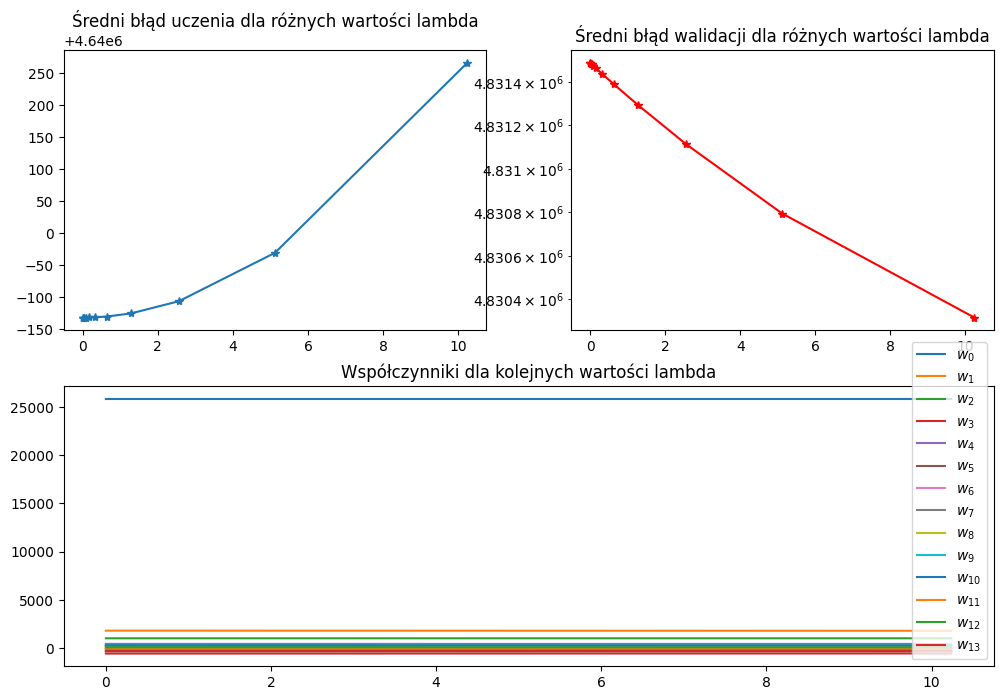

In [50]:
x= scaler.fit_transform(x)
ridge_best_alpha = ridge_find_alpha(x, y)
print(ridge_best_alpha)

C:\Users\justy\AppData\Local\Temp\ipykernel_28688\465976509.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
C:\Users\justy\AppData\Local\Temp\ipykernel_28688\465976509.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")


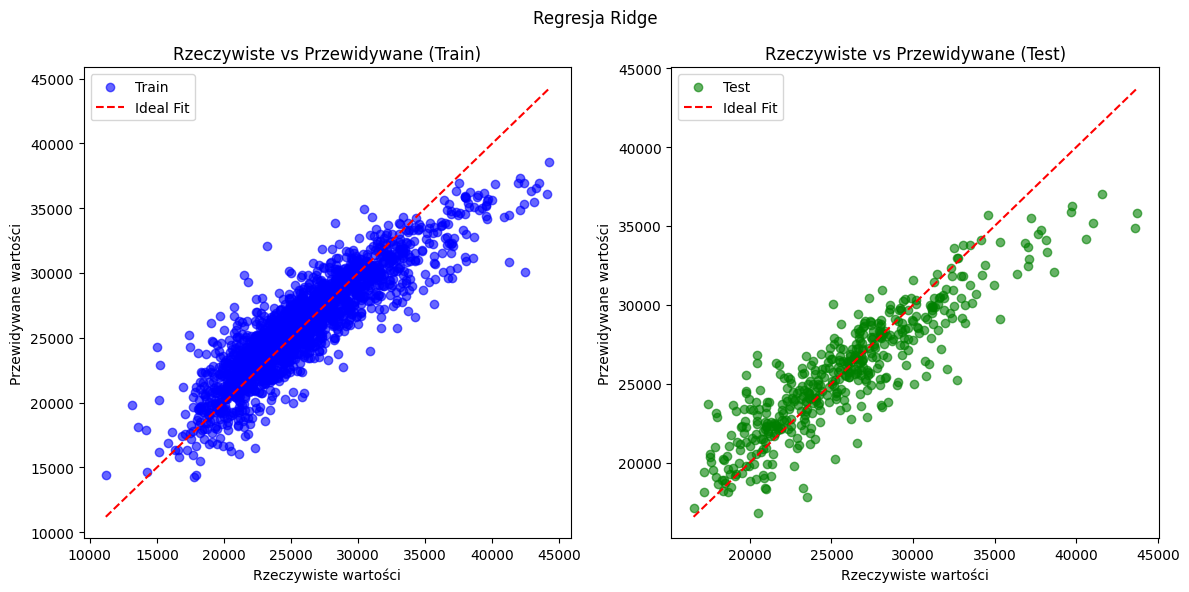

Mean Squared Error for train: 4889134.308505234
Mean Squared Error for test: 5004437.649662683
R2 Score for train: 0.7900562237369898
R2 Score for test: 0.7902903927920106
Coefficients: [-9947.95027942  8311.36309618  -510.50069548   878.04643902
  -422.93102783 -2386.84609271   200.19491392 -2703.6750744
   818.15150046  -261.74659428   120.46715995  -228.88747042
  1454.52378559 -1450.16501756  1736.12740906    29.86420497
  -247.57502838  1228.08400231 -1679.28714309  1040.06812459
  -392.52585465  5908.84404763  -458.8805224 ]


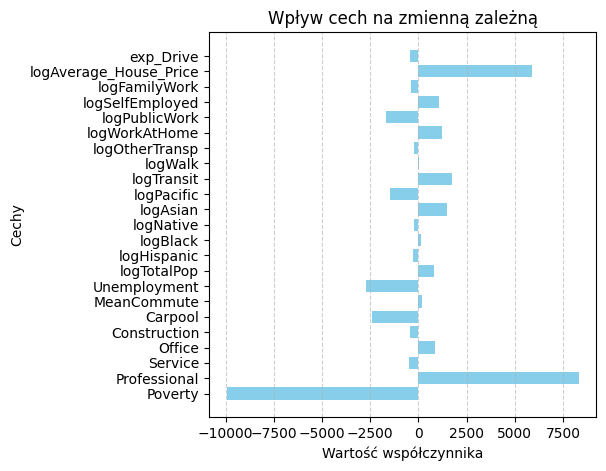

In [53]:
e_train2, e_test2, r2_train2, r2_test2, coefs2 = ridge_regression(X_train1, X_test1, y_train1, y_test1, ridge_best_alpha)
print('Mean Squared Error for train:', e_train2)
print('Mean Squared Error for test:', e_test2)
print('R2 Score for train:', r2_train2)
print('R2 Score for test:', r2_test2)
print('Coefficients:', coefs2)

plt.figure(figsize=(5, 5))
plt.barh(X1.columns.values, coefs2, color='skyblue')
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cechy")
plt.title("Wpływ cech na zmienną zależną")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

C:\Users\justy\AppData\Local\Temp\ipykernel_28688\465976509.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
C:\Users\justy\AppData\Local\Temp\ipykernel_28688\465976509.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")


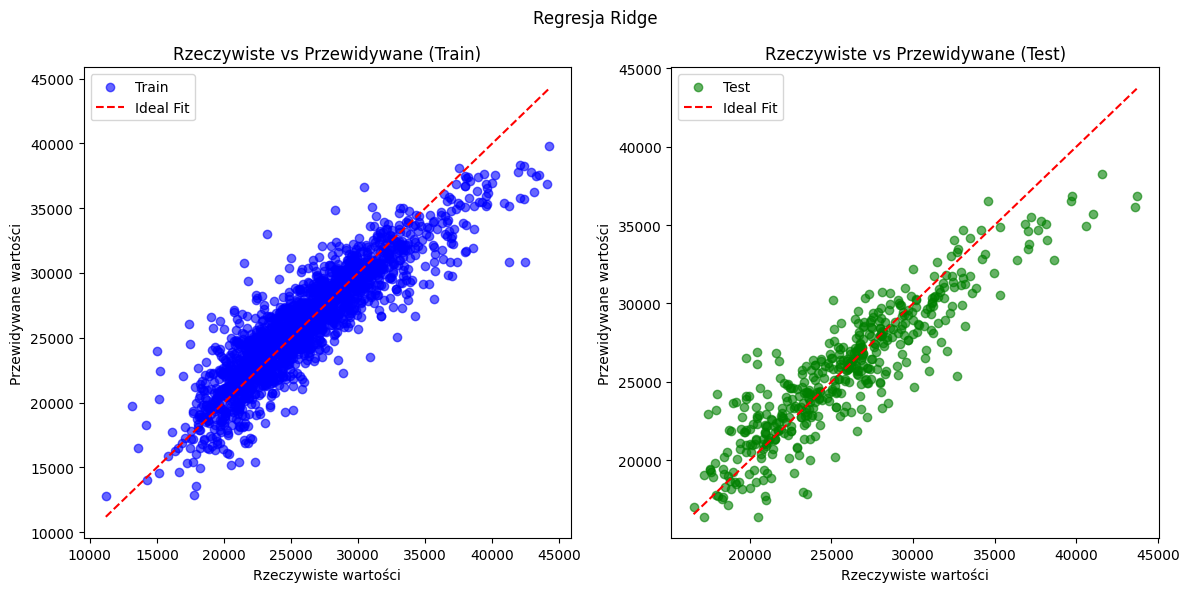

Mean Squared Error for train: 4706371.146286229
Mean Squared Error for test: 4527490.773100809
R2 Score for train: 0.7979042364968925
R2 Score for test: 0.8102767227545009
Coefficients: [-2078.23290746  1726.39254415   952.94637002  -530.10115257
   402.51987553  -327.36764392  -187.97959761  -109.34728073
   228.39134839   192.80221238   233.2198852    -26.97390423
   163.74876333  -153.71769417]


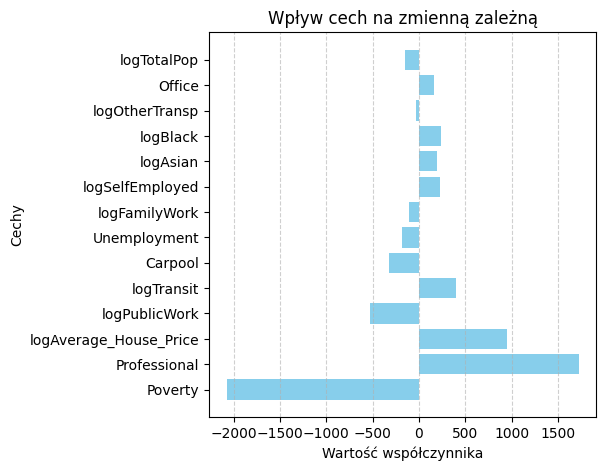

In [55]:
e_train3, e_test3, r2_train3, r2_test3, coefs3 = ridge_regression(x_train, x_test, y_train, y_test, ridge_best_alpha)
print('Mean Squared Error for train:', e_train3)
print('Mean Squared Error for test:', e_test3)
print('R2 Score for train:', r2_train3)
print('R2 Score for test:', r2_test3)
print('Coefficients:', coefs3)


plt.figure(figsize=(5, 5))
plt.barh(best_features, coefs3, color='skyblue')
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cechy")
plt.title("Wpływ cech na zmienną zależną")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


c:\Users\justy\OneDrive - Politechnika Warszawska\Environments\my_env\Lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\justy\OneDrive - Politechnika Warszawska\Environments\my_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\justy\OneDrive - Politechnika Warszawska\Environments\my_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.026e+09, tolerance: 4.092e+06 Linear regression models with null weight for the l1 regularization term are more 

14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
[2154.0352656736754, 2154.0352662868813, 2154.035268136201, 2154.0352755440736, 2154.03530512445, 2154.0354236219655, 2154.0358968861583, 2154.037779174276, 2154.0452938297453, 2154.0753411595556, 2154.1959210083824, 2154.678463066358, 2156.5985312084254, 2162.668691945818, 2175.259545881142, 2195.7355038765936, 2254.320548277565, 2433.4733368259303, 2825.7896621116743, 3968.0820854834187, 4834.932485968136]
[2198.064274075001, 2198.064463693201, 2198.064675282466, 2198.0649320581456, 2198.0655973998214, 2198.0669634192777, 2198.070110349837, 2198.0779686906317, 2198.0968145160464, 2198.1544767265154, 2198.3335673086003, 2198.944106211377, 2201.151922339298, 2204.229723903116, 2211.3973303945163, 2228.037776886262, 2286.6047970193513, 2455.272572522454, 2848.6560719194026, 4005.9730536482257, 4863.536355019892]
Best lambda: 0
0


Text(0.5, 1.0, 'Współczynniki dla kolejnych wartości lambda')

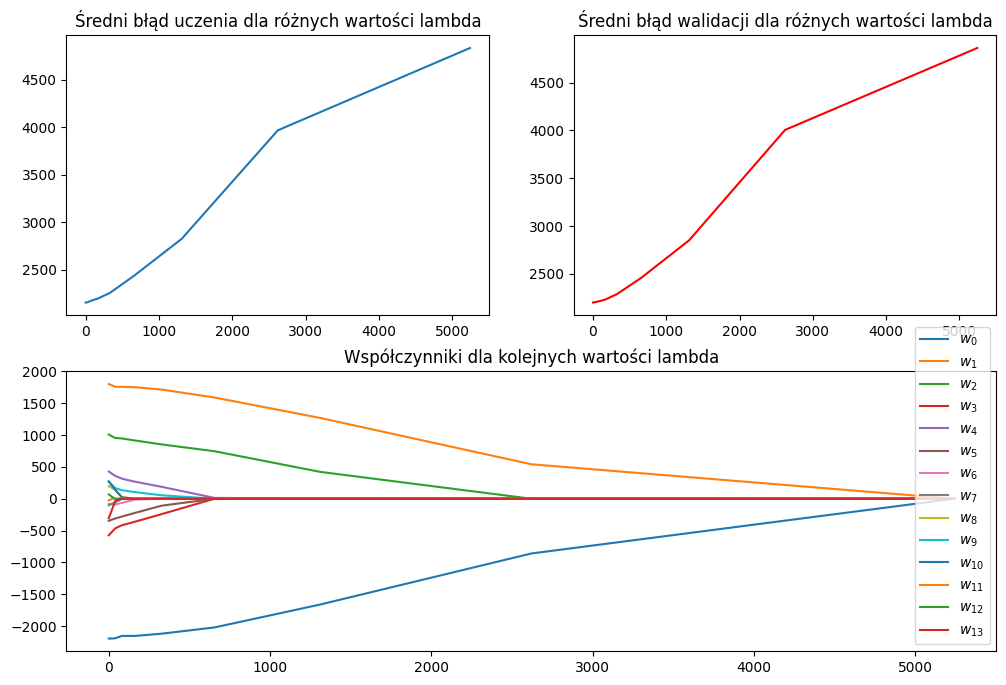

In [56]:
# Miejsce na kod
from sklearn.model_selection import cross_validate
import matplotlib.gridspec as gridspec
from math import sqrt
import numpy as np
from matplotlib import pyplot as plt

parameters = [0.01 * 2**i for i in range(20)]
parameters.insert(0, 0)
train_scores = []
test_scores = []
ws = []

for lamb in parameters:
    result = cross_validate(Lasso(alpha = lamb), scaler.fit_transform(x), y, return_train_score = True, cv = 5, scoring = 'neg_mean_squared_error', return_estimator = True)
    train_scores.append(sqrt(np.mean(-result['train_score'])))
    test_scores.append(sqrt(np.mean(-result['test_score'])))
    best_model: Lasso = result['estimator'][np.argmax(result['test_score'])]
    coefficients = best_model.coef_
    print(len(coefficients))
    # coefficients[0][0] = best_model.intercept_
    # print(coefficients.flatten().tolist())
    ws.append(coefficients.flatten().tolist())

# print(ws)
print(train_scores)
print(test_scores)
best_lambda = parameters[np.argmin(test_scores)]
print('Best lambda:', best_lambda)
gs = gridspec.GridSpec(2, 2)
fig = plt.figure(figsize=(12,8))

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(parameters, train_scores)
plt.title('Średni błąd uczenia dla różnych wartości lambda')


print(np.argmin(test_scores))
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(parameters, test_scores, 'red')
# plt.yscale('log')
plt.title('Średni błąd walidacji dla różnych wartości lambda')

# ax -> plt

ax3 = fig.add_subplot(gs[1, :])
for i in range(len(best_features)):
    ax3.plot(parameters, [w[i] for w in ws])
plt.legend([f'$w_{{{i}}}$' for i in range(len(best_features))], loc='lower right')
plt.title('Współczynniki dla kolejnych wartości lambda')

In [62]:
def lasso_find_alpha(x, y):
    parameters = [0.01 * 2**i for i in range(20)]
    parameters.insert(0, 0)
    train_scores = []
    test_scores = []
    ws = []

    for lamb in parameters:
        result = cross_validate(Lasso(alpha = lamb), scaler.fit_transform(x), y, return_train_score = True, cv = 5, scoring = 'neg_mean_squared_error', return_estimator = True)
        train_scores.append(sqrt(np.mean(-result['train_score'])))
        test_scores.append(sqrt(np.mean(-result['test_score'])))
        best_model: Lasso = result['estimator'][np.argmax(result['test_score'])]
        coefficients = best_model.coef_
        print(len(coefficients))
        # coefficients[0][0] = best_model.intercept_
        # print(coefficients.flatten().tolist())
        ws.append(coefficients.flatten().tolist())

    # print(ws)
    print(train_scores)
    print(test_scores)
    best_lambda = parameters[np.argmin(test_scores)]
    print('Best lambda:', best_lambda)
    gs = gridspec.GridSpec(2, 2)
    fig = plt.figure(figsize=(12,8))

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(parameters, train_scores)
    plt.title('Średni błąd uczenia dla różnych wartości lambda')


    print(np.argmin(test_scores))
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(parameters, test_scores, 'red')
    # plt.yscale('log')
    plt.title('Średni błąd walidacji dla różnych wartości lambda')

    # ax -> plt

    ax3 = fig.add_subplot(gs[1, :])
    for i in range(len(best_features)):
        ax3.plot(parameters, [w[i] for w in ws])
    plt.legend([f'$w_{{{i}}}$' for i in range(len(best_features))], loc='lower right')
    plt.title('Współczynniki dla kolejnych wartości lambda')

    return best_lambda

c:\Users\justy\OneDrive - Politechnika Warszawska\Environments\my_env\Lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\justy\OneDrive - Politechnika Warszawska\Environments\my_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\justy\OneDrive - Politechnika Warszawska\Environments\my_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.026e+09, tolerance: 4.092e+06 Linear regression models with null weight for the l1 regularization term are more 

14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
[2154.0352656736754, 2154.0352662868813, 2154.035268136201, 2154.0352755440736, 2154.03530512445, 2154.0354236219655, 2154.0358968861583, 2154.037779174276, 2154.0452938297453, 2154.0753411595556, 2154.1959210083824, 2154.678463066358, 2156.5985312084254, 2162.668691945818, 2175.259545881142, 2195.7355038765936, 2254.320548277565, 2433.4733368259303, 2825.7896621116743, 3968.0820854834187, 4834.932485968136]
[2198.064274075001, 2198.064463693201, 2198.064675282466, 2198.0649320581456, 2198.0655973998214, 2198.0669634192777, 2198.070110349837, 2198.0779686906317, 2198.0968145160464, 2198.1544767265154, 2198.3335673086003, 2198.944106211377, 2201.151922339298, 2204.229723903116, 2211.3973303945163, 2228.037776886262, 2286.6047970193513, 2455.272572522454, 2848.6560719194026, 4005.9730536482257, 4863.536355019892]
Best lambda: 0
0
0


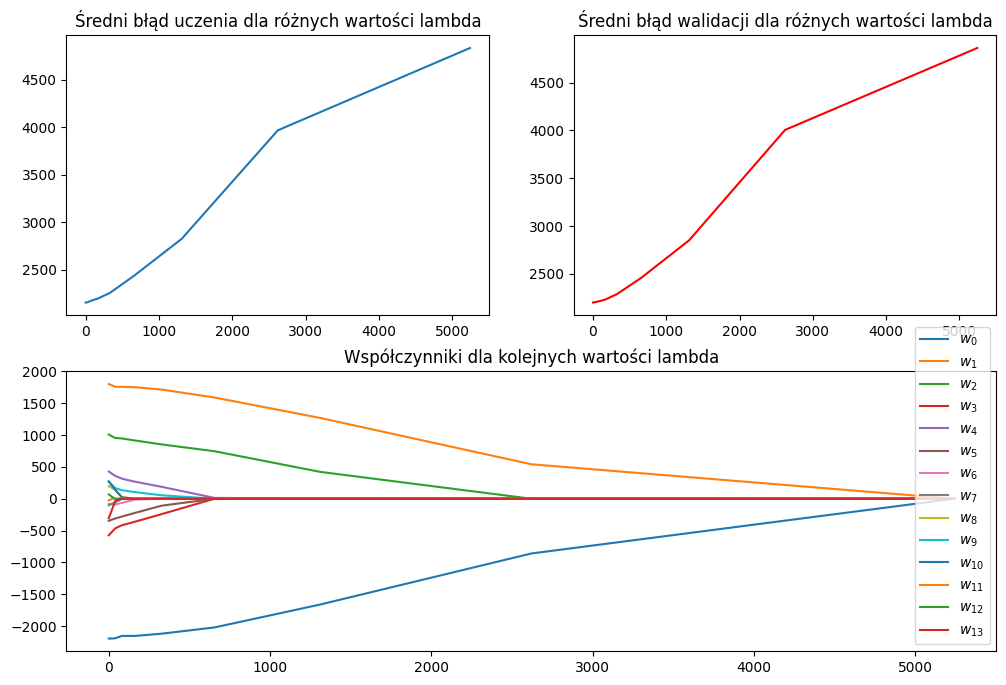

In [63]:
lasso_best_alpha = lasso_find_alpha(x, y)
print(lasso_best_alpha)

c:\Users\justy\OneDrive - Politechnika Warszawska\Environments\my_env\Lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\justy\OneDrive - Politechnika Warszawska\Environments\my_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\justy\OneDrive - Politechnika Warszawska\Environments\my_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.255e+09, tolerance: 4.334e+06 Linear regression models with null weight for the l1 regularization term are more 

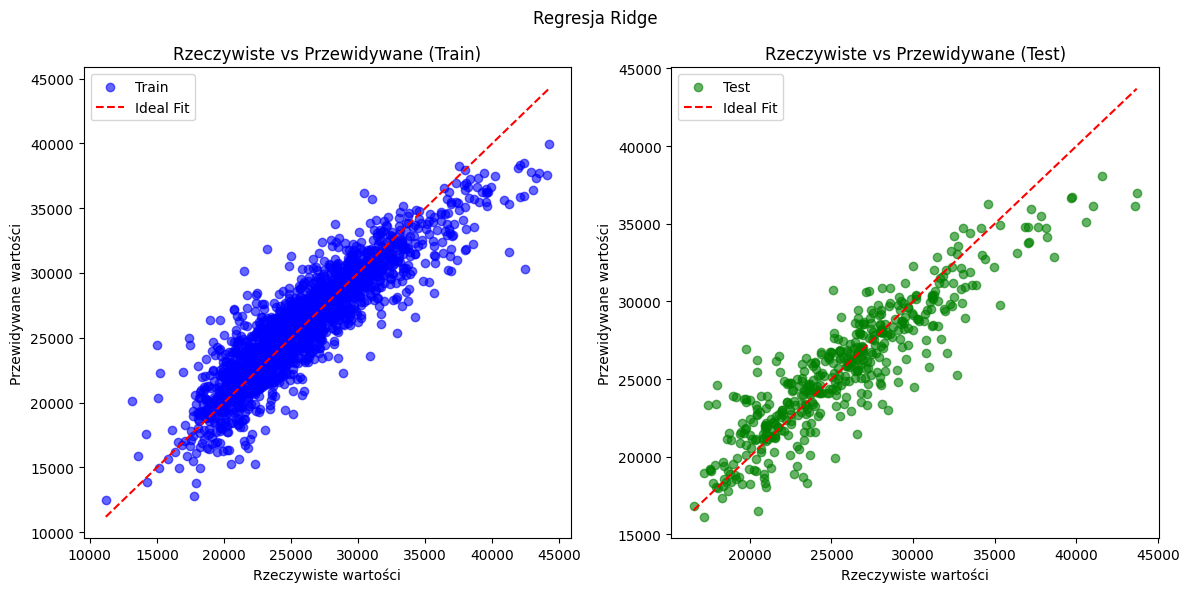

Mean Squared Error for train: 4573114.533389418
Mean Squared Error for test: 4480379.550599859
R2 Score for train: 0.8036263939910947
R2 Score for test: 0.8122509058011073
Coefficients: [-12997.47244264  11996.59301217   1296.8458752    1233.82684507
    987.2745449   -3790.87114306   -184.88425201  -1122.27854509
   -221.91131261   -690.46336726    886.78343156    -81.79625161
    994.35161555  -1505.96676201   1499.24344799  -1366.66518673
   -782.90811123  -2096.71884094  -3279.6077812    1461.78152208
   -395.34241883   5910.25016484  -3099.86088151]


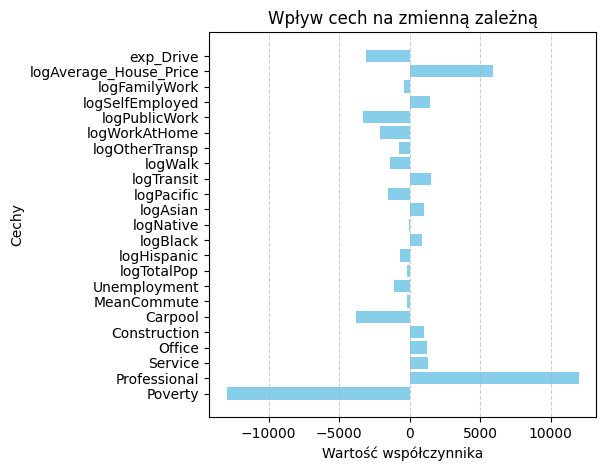

In [67]:
e_train4, e_test4, r2_train4, r2_test4, coefs4 = lasso_regression(X_train1, X_test1, y_train1, y_test1, lasso_best_alpha)
print('Mean Squared Error for train:', e_train4)
print('Mean Squared Error for test:', e_test4)
print('R2 Score for train:', r2_train4)
print('R2 Score for test:', r2_test4)
print('Coefficients:', coefs4)

plt.figure(figsize=(5, 5))
plt.barh(X1.columns.values, coefs4, color='skyblue')
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cechy")
plt.title("Wpływ cech na zmienną zależną")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

c:\Users\justy\OneDrive - Politechnika Warszawska\Environments\my_env\Lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\justy\OneDrive - Politechnika Warszawska\Environments\my_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\justy\OneDrive - Politechnika Warszawska\Environments\my_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.379e+09, tolerance: 4.334e+06 Linear regression models with null weight for the l1 regularization term are more 

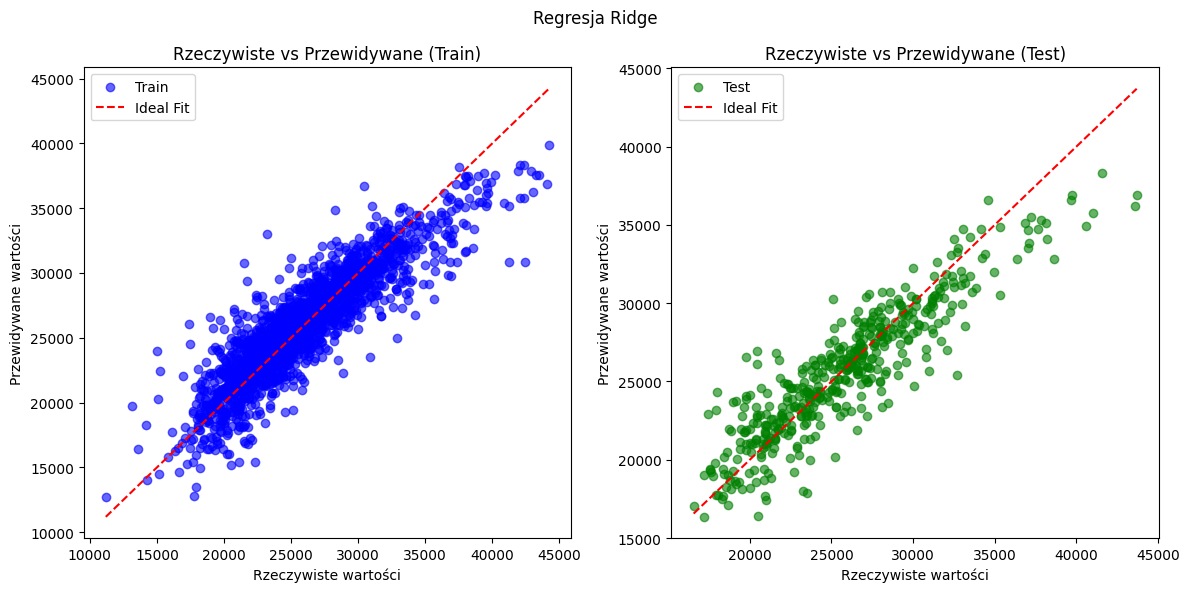

Mean Squared Error for train: 4706006.362868562
Mean Squared Error for test: 4517430.231263012
R2 Score for train: 0.7979199006213347
R2 Score for test: 0.8106983070412481
Coefficients: [-2095.88110166  1740.28273288   951.74682788  -538.43331045
   404.88295724  -324.91887765  -174.30669971  -110.08799519
   228.91827731   191.57606584   242.76604792   -26.12355171
   165.07237576  -169.33033023]


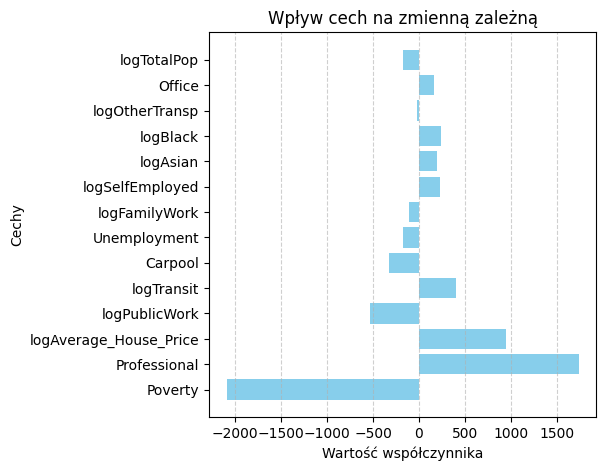

In [68]:
e_train5, e_test5, r2_train5, r2_test5, coefs5 = lasso_regression(x_train, x_test, y_train, y_test, lasso_best_alpha)
print('Mean Squared Error for train:', e_train5)
print('Mean Squared Error for test:', e_test5)
print('R2 Score for train:', r2_train5)
print('R2 Score for test:', r2_test5)
print('Coefficients:', coefs5)

plt.figure(figsize=(5, 5))
plt.barh(best_features, coefs5, color='skyblue')
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cechy")
plt.title("Wpływ cech na zmienną zależną")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


### Raport

Praca nad analizą naszego zbioru i budowaniem modelu przebiegała następująco:

W I etapie:
Wybraliśmy do analizy zbiór danych CENSUS (https://www.kaggle.com/datasets/muonneutrino/us-census-demographic-data). Określiliśmy cel naszej analizy: Predykcja dochodu na mieszkańca w zależności od danych demograficznych i ekonomicznych w Stanach Zjednoczonych w 2017 roku (na poziomie hrabstw).

W II etapie:
1) Przedstawiliśmy podstawowe statystyki danych oraz połączyliśmy wybrany zbiór danych ze zbiorem danych z Zillow (https://www.zillow.com/), na podstawie nazwy stanu i hrabstwa, dla odpowiedniego roku. Dodaliśmy w ten sposób kolejny atrybut o dużej istotności dla rozważanego zbioru, czyli średnią wartość nieruchomości. Przez braki danych w zbiorze z Zillow ilość rekordów spadła z 3219 do 2894.
2) Na podstawie wykresów pudełkowych, histogramów i rozszerzonych podstawowych statystyk danych (średnia, mediana, moda) określiliśmy, które ze zmiennych są lewo, bądź prawo skośne.
3) Określiliśmy korelację między atrybutami opisującymi, wskazując te atrybuty, które są mocno/bardzo słabo skorelowane z atrybutem decyzyjnym oraz te atrybutu opisujące, które mają wysoką korelację między sobą i są zbędne. Te atrubuty, to: `Men`, `Women`, `VotingAgeCitizen`, `Employed`, `ChildPoverty`, `Income`, `IncomeErr`, `IncomePerCapErr`. Również usunęliśmy atrybut `CountyId`, ponieważ po analizie zdecydowaliśmy, że jedynym jego znaczenie było indeksowanie danych.
4) Usunęliśmy wartości odstające z danych, stosując miarę odległości od średniej wartości jako 3 odchylenia standardowe, co zmniejszyło liczbę rekordów z 2894 do 2327. Zdecydowaliśmy, się na taką miarę, ponieważ pozostała znana metoda IQR, czyli odległość 1,5 wartości odchylenia standardowego pozostawiała jedynie ok 600 rekordów.
5) Po otrzymaniu zbioru gotowego do doboru cech i trenowania modleu regresji sprawdziliśmy ponownie podstawowe statystki danych, korelację i rozkłady zmiennych. Zweryfikowaliśmy w ten sposób, że atrybuty opisujące mają rozkład bardziej zbliżony do normalnego.
6) Wykonaliśmy wizualizacji w postaci naniesienia informacji o liczbie ludności oraz dochodzie na mieszkańca i usuniętych hrabstwach na mapę Stanów Zjednoczonych.
7) Postawiliśmy hipotezę badawczą, w której określiliśmy, że największy wpływ na atrybut decyzyjny będą miały: ceny nieruchomości, zróżnicowanie rasowe, sektor gospodarki oraz wskaźnik ubóstwa w regionie.

W III etapie:
1) Dokonaliśmy transformacji wcześniej wspomnianych atrybutów, z rozkładu lewo/prawo skośnego do rozkładu bardziej przypominającego normalny na podstawie wyników testu Shapiro-Wilk. Zastosowaliśmy dobór logarytmu o najlepszej podstawie dla danych prawo skośnych i dobór najlepszego wykładnika dla danych lewo skośnych.